# Human demo charts (rapid prototype)

Prototype RL-page human charts **without Flask**. Data via `data_upset`.

Hand layout (2×2):
```
[0 top-L] [1 top-R]   ← public
[2 bot-L] [3 bot-R]   ← private (deal)
```

Board charts (same layout):
1. Action mix by slot (take / keep / flip)
2. Which card flipped (draw-flip heat)
3. **Strategy board** — replace (take+keep) vs reveal (flip)

Re-run **Reload + fetch** after editing `data_upset.py`.


In [25]:
from __future__ import annotations

import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
BACKEND = None
for p in [HERE, HERE / "backend", HERE.parent, HERE.parent.parent]:
    if (p / "data_upset.py").exists():
        BACKEND = p.resolve()
        break
if BACKEND is None:
    raise FileNotFoundError("Could not find data_upset.py")

if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
os.chdir(BACKEND)
print("cwd:", Path.cwd())

cwd: C:\Users\kbwil\Documents\Data_Projects\golf\Golf_solver\backend


In [26]:
import data_upset

data_upset = importlib.reload(data_upset)
summary = data_upset.fetch_human_demo_score_summary()
abr = summary.get("action_by_round") or {}
abb = summary.get("action_by_board") or {}
print("holes", summary.get("holes"), "steps", summary.get("steps"))
print("board mode", abb.get("mode"), "rounds", abb.get("rounds"), "classified", abb.get("steps_classified"))

holes 57 steps 233
board mode hand_2x2 rounds [1, 2, 3, 4] classified 233


## Score histogram

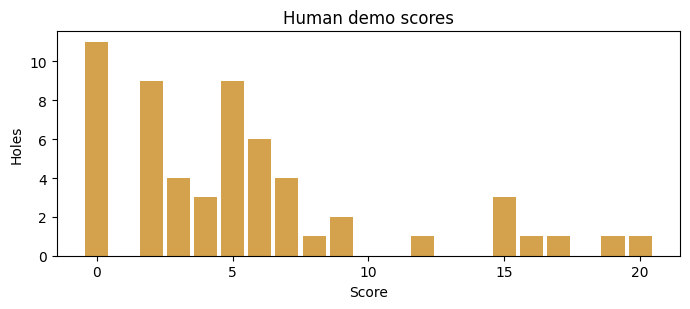

In [27]:
hist = summary.get("score_histogram") or {}
if hist.get("available"):
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.bar(hist["bin_centers"], hist["counts"], color="#d4a24c", width=0.85)
    ax.set_xlabel("Score"); ax.set_ylabel("Holes"); ax.set_title("Human demo scores")
    plt.tight_layout(); plt.show()
else:
    print("no hist")

## Action mix by round

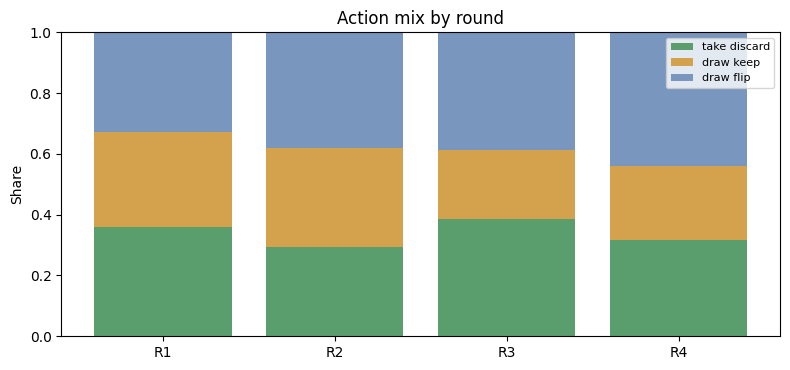

In [28]:
def plot_action_by_round(abr: dict):
    if not abr.get("available"):
        print("No action_by_round"); return
    rounds, share = abr["rounds"], abr["share"]
    types = abr.get("types") or ["take_discard", "draw_keep", "draw_flip"]
    colors = {"take_discard": "#5a9e6e", "draw_keep": "#d4a24c", "draw_flip": "#7896be"}
    x = np.arange(len(rounds)); bottom = np.zeros(len(rounds))
    fig, ax = plt.subplots(figsize=(8, 3.8))
    for t in types:
        vals = np.array(share.get(t) or [0] * len(rounds), dtype=float)
        ax.bar(x, vals, bottom=bottom, label=t.replace("_", " "), color=colors[t])
        bottom += vals
    ax.set_xticks(x); ax.set_xticklabels([f"R{r}" for r in rounds])
    ax.set_ylim(0, 1); ax.set_ylabel("Share"); ax.set_title("Action mix by round")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

plot_action_by_round(abr)

## Action mix by card slot (2×2)

Not “which card flipped.” Each equal-height cell is a **100% stacked** take / keep / flip mix for actions that targeted that slot. No card border. Top = public, bottom = private.

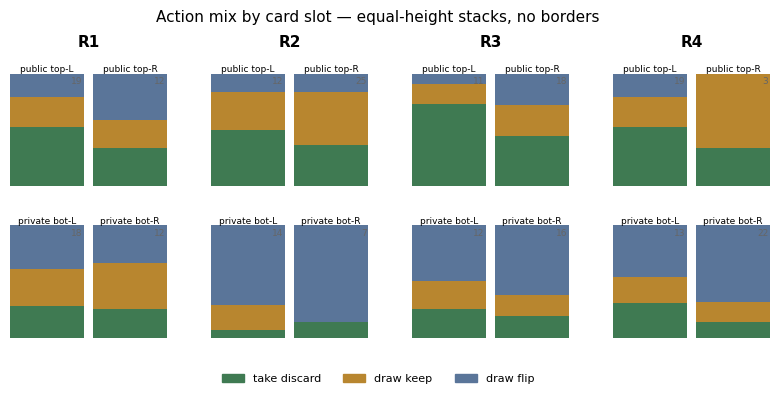

In [29]:
def plot_hand_grid_by_round(abb: dict):
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    rounds = abb["rounds"]
    types = abb["types"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    colors = {"take_discard": "#3f7a52", "draw_keep": "#b8862f", "draw_flip": "#5a7599"}
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    n_r = len(rounds)

    fig = plt.figure(figsize=(max(8, 2.0 * n_r), 4.0))
    outer = fig.add_gridspec(
        2, n_r, height_ratios=[0.08, 1.0], hspace=0.02, wspace=0.28,
        left=0.04, right=0.99, top=0.88, bottom=0.16,
    )
    for ri, rn in enumerate(rounds):
        ax_lab = fig.add_subplot(outer[0, ri])
        ax_lab.axis("off")
        ax_lab.set_title(f"R{rn}", fontsize=11, fontweight="bold", pad=0)

        inner = outer[1, ri].subgridspec(2, 2, wspace=0.12, hspace=0.35)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                tot = float(abb["totals"][ri][pos] or 0)
                bottom = 0.0
                if tot > 0:
                    for t in types:
                        v = float(abb["counts"][t][ri][pos]) / tot
                        if v <= 0:
                            continue
                        ax.bar([0], [v], bottom=bottom, color=colors[t], width=1.0, linewidth=0)
                        bottom += v
                ax.set_xlim(-0.5, 0.5)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                ax.set_facecolor("none")
                role = "private" if pos >= 2 else "public"
                ax.set_title(f"{role} {labels[pos]}", fontsize=6.5, pad=1)
                if tot:
                    ax.text(
                        0.98, 0.97, str(int(tot)), transform=ax.transAxes,
                        ha="right", va="top", fontsize=6.5, color="#666",
                    )

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[t], label=t.replace("_", " "))
        for t in types
    ]
    fig.suptitle("Action mix by card slot — equal-height stacks, no borders", fontsize=11, y=0.98)
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=3,
        fontsize=8,
        frameon=False,
    )
    plt.show()


plot_hand_grid_by_round(abb)


## Which card flipped each round

Draw-and-flip only. Same 2×2 layout; **darker = larger share of that round’s flips**.

**Score filter:** keep holes with final score ≤ *N* (slider below). Cell counts/% recompute from that subset — same idea as the `/rl` UI.


ipywidgets unavailable ( No module named 'ipywidgets' ) — static all-scores plot


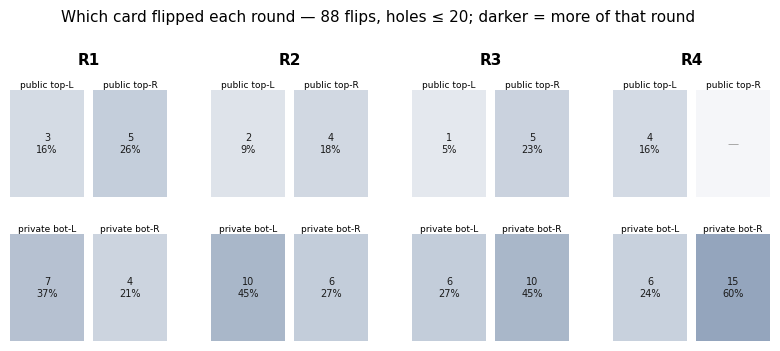

In [30]:
def flip_matrix_for_max_score(abb: dict, max_score: int | None):
    by = abb.get("draw_flip_by_score") or {}
    rounds = abb.get("rounds") or []
    n_pos = len(abb.get("positions") or [0, 1, 2, 3])
    if max_score is None or not by:
        return abb["counts"]["draw_flip"]
    mat = [[0] * n_pos for _ in rounds]
    for key, src in by.items():
        try:
            sc = int(key)
        except (TypeError, ValueError):
            continue
        if sc > max_score:
            continue
        for ri, row in enumerate(src):
            for pos, v in enumerate(row):
                mat[ri][pos] += int(v or 0)
    return mat


def plot_flips_by_round(abb: dict, max_score: int | None = None):
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    rounds = abb["rounds"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    flip = flip_matrix_for_max_score(abb, max_score)
    n_r = len(rounds)
    n_flip = int(sum(sum(row) for row in flip))

    fig = plt.figure(figsize=(max(8, 2.0 * n_r), 3.6))
    outer = fig.add_gridspec(
        2, n_r, height_ratios=[0.08, 1.0], hspace=0.02, wspace=0.28,
        left=0.04, right=0.99, top=0.82, bottom=0.06,
    )
    for ri, rn in enumerate(rounds):
        ax_lab = fig.add_subplot(outer[0, ri])
        ax_lab.axis("off")
        ax_lab.set_title(f"R{rn}", fontsize=11, fontweight="bold", pad=0)

        row_counts = flip[ri]
        round_tot = float(sum(row_counts) or 0)
        inner = outer[1, ri].subgridspec(2, 2, wspace=0.12, hspace=0.35)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                v = float(row_counts[pos])
                share = (v / round_tot) if round_tot else 0.0
                alpha = 0.12 + 0.88 * share if v else 0.06
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                ax.set_facecolor((90 / 255, 117 / 255, 153 / 255, alpha))
                role = "private" if pos >= 2 else "public"
                ax.set_title(f"{role} {labels[pos]}", fontsize=6.5, pad=1)
                if v:
                    ax.text(
                        0.5, 0.5, f"{int(v)}\n{share:.0%}", transform=ax.transAxes,
                        ha="center", va="center", fontsize=7, color="#1a1a1a",
                    )
                else:
                    ax.text(
                        0.5, 0.5, "—", transform=ax.transAxes,
                        ha="center", va="center", fontsize=8, color="#999",
                    )

    score_bit = f", holes ≤ {max_score}" if max_score is not None else ""
    fig.suptitle(
        f"Which card flipped each round — {n_flip} flips{score_bit}; darker = more of that round",
        fontsize=11,
    )
    plt.show()


# Interactive ≤ score slider (falls back to static plot if ipywidgets missing)
_lo = abb.get("flip_score_min")
_hi = abb.get("flip_score_max")
if abb.get("draw_flip_by_score") and _lo is not None and _hi is not None:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        _slider = widgets.IntSlider(
            value=int(_hi),
            min=int(_lo),
            max=int(_hi),
            step=1,
            description="score ≤",
            continuous_update=True,
            style={"description_width": "initial"},
            layout=widgets.Layout(width='70%'),
        )
        _out = widgets.interactive_output(
            lambda max_score: plot_flips_by_round(abb, int(max_score)),
            {"max_score": _slider},
        )
        display(_slider, _out)
    except Exception as e:
        print("ipywidgets unavailable (", e, ") — static all-scores plot")
        plot_flips_by_round(abb, int(_hi))
else:
    print("No scored flips for slider; showing all flips")
    plot_flips_by_round(abb)


## Strategy board: replace vs reveal (combined)

Same 2×2 × round layout. Each cell collapses take+keep into **replace** vs **reveal** (draw-flip).  
Read it as: *are humans upgrading this slot or still opening it?* Typical Golf: early rounds reveal public (top); later rounds replace private (bottom).


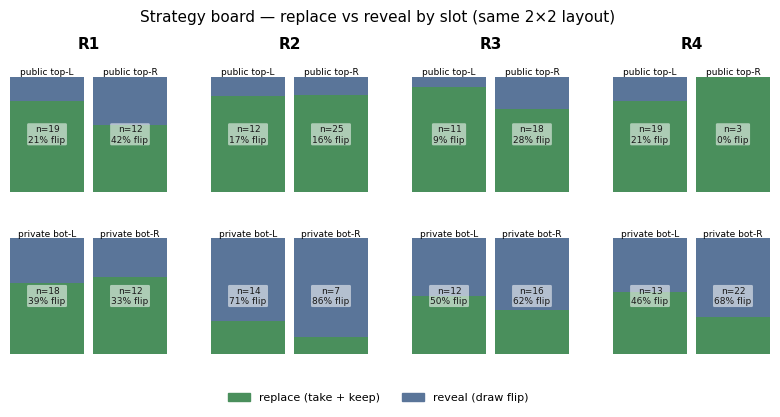

In [31]:
def plot_replace_vs_reveal(abb: dict):
    """Combine action-mix + flip charts: replace (take+keep) vs reveal (flip)."""
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    rounds = abb["rounds"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    n_r = len(rounds)
    colors = {"replace": "#4a8f5c", "reveal": "#5a7599"}

    fig = plt.figure(figsize=(max(8, 2.0 * n_r), 4.2))
    outer = fig.add_gridspec(
        2, n_r, height_ratios=[0.08, 1.0], hspace=0.02, wspace=0.28,
        left=0.04, right=0.99, top=0.88, bottom=0.16,
    )
    for ri, rn in enumerate(rounds):
        ax_lab = fig.add_subplot(outer[0, ri])
        ax_lab.axis("off")
        ax_lab.set_title(f"R{rn}", fontsize=11, fontweight="bold", pad=0)

        inner = outer[1, ri].subgridspec(2, 2, wspace=0.12, hspace=0.4)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                take = float(abb["counts"]["take_discard"][ri][pos])
                keep = float(abb["counts"]["draw_keep"][ri][pos])
                flip = float(abb["counts"]["draw_flip"][ri][pos])
                replace = take + keep
                tot = replace + flip
                if tot > 0:
                    ax.bar([0], [replace / tot], bottom=0.0, color=colors["replace"], width=1.0, linewidth=0)
                    ax.bar([0], [flip / tot], bottom=replace / tot, color=colors["reveal"], width=1.0, linewidth=0)
                ax.set_xlim(-0.5, 0.5)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                ax.set_facecolor("none")
                role = "private" if pos >= 2 else "public"
                ax.set_title(f"{role} {labels[pos]}", fontsize=6.5, pad=1)
                if tot:
                    ax.text(
                        0.5, 0.5,
                        f"n={int(tot)}\n{flip / tot:.0%} flip",
                        transform=ax.transAxes,
                        ha="center", va="center", fontsize=6.5, color="#1a1a1a",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.55, edgecolor="none"),
                    )
                else:
                    ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha="center", va="center",
                            fontsize=8, color="#999")

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["replace"], label="replace (take + keep)"),
        plt.Rectangle((0, 0), 1, 1, color=colors["reveal"], label="reveal (draw flip)"),
    ]
    fig.suptitle(
        "Strategy board — replace vs reveal by slot (same 2×2 layout)",
        fontsize=11,
        y=0.98,
    )
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=2,
        fontsize=8,
        frameon=False,
    )
    plt.show()


plot_replace_vs_reveal(abb)

## Raw peek

In [32]:
rows = (
    data_upset.supabase.table("human_demos")
    .select("round_num,action,action_key,created_at")
    .neq("game_id", "test_probe")
    .limit(8)
    .execute()
).data or []
for r in rows:
    pos = data_upset._action_target_pos(r.get("action"), r.get("action_key"))
    at = data_upset._classify_human_action(r.get("action"), r.get("action_key"))
    print(r.get("round_num"), at, "pos", pos, r.get("action_key"))

1 take_discard pos 0 ak
1 take_discard pos 0 take_discard_0
2 draw_keep pos 0 draw_deck_0
1 take_discard pos 2 take_discard_2
2 draw_flip pos 3 draw_deck_flip_3
3 take_discard pos 1 take_discard_1
4 draw_flip pos 0 draw_deck_flip_0
1 draw_flip pos 3 draw_deck_flip_3
